
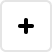
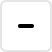
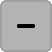
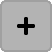
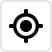
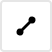
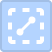
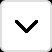
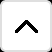
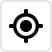
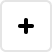
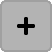
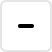
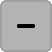
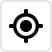
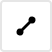
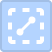
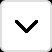
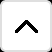
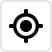

In [1]:
import numpy as np
import pandas as pd
from lets_plot import *
LetsPlot.setup_html()

In [2]:
np.random.seed(42)

In [3]:
n = 50
x = np.arange(n)
y = x + np.random.normal(scale=10, size=n)
group = np.random.choice(['a', 'b'], size=n)

In [4]:
plot = ggplot({'x': x, 'y': y}, aes(x='x', y='y')) + geom_point()

`smooth_labels()` без параметров и вызова функций выводит строку вида R^2=0.662373

In [5]:
plot + geom_smooth(labels = smooth_labels())

Во всех других случаях значение выводится без левой части. Пользователь может самостоятельно оформить строку по своему желанию.

In [6]:
gggrid([     
    plot + geom_smooth(labels = smooth_labels(['..r2..'])),
    plot + geom_smooth(labels = smooth_labels().line('@..r2..')),
    plot + geom_smooth(labels = smooth_labels().line('R\\^2 = @..r2..')),
])

У других переменных нет дефолтных левых частей.

In [7]:
gggrid([     
    plot + geom_smooth(labels = smooth_labels(['..adjr2..'])),
    plot + geom_smooth(labels = smooth_labels().line('@..adjr2..')),
    plot + geom_smooth(labels = smooth_labels().line('R_adj\\^2 = @..adjr2..'))    
])

Для форматирования значений используется обычная функция `format()`

In [8]:
gggrid([    
    plot + geom_smooth(labels = smooth_labels().format('..r2..', '.2f')), 
    plot + geom_smooth(labels = smooth_labels().line('@..r2..').format('..r2..', '.2f'))
])

#### Формула

In [9]:
n2 = 100
x2 = np.linspace(-2, 2, n2)
y2 = x2 ** 2 + np.random.normal(size=n2)
plot2 = ggplot({'x': x2, 'y': y2}, aes(x='x', y='y')) 

Для вывода формулы используем `~eq`. 

`~eq` представляет равенство целиком (включает левую часть `y=`) и настраивается с помощью функции `eq(lhs, rhs, format, threshold)` 

In [10]:
plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq'))

Параметры `lhs` и `rhs`

In [11]:
gggrid([   
    # Заменяет 'y' на f(x) в левой части формулы, знак '=' сохраняется 
    plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq').eq(lhs='f(x)')),
    # Полностью удаляет левую часть формулы
    plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq').eq(lhs='')), 
    # Заменяет 'x' на 't' в правой части формулы
    plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq').eq(rhs='t')), 
])

Форматирование коэффициентов

In [12]:
gggrid([   
    # Обычный format() применяется ко всем коэффициентам
    plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq').format('~eq', '.1f')),
    # Один для всех.
    plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq').eq(format = '.2f')), 
    # Можно передать список для каждого коэффициента в отдельности. 
    # Длинна списка может не совпадать с количесвом коэффициентов, 
    # тогда последний в списке примениться для оставшихся коэффициентов
    plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq').eq(format = ['.1f', '.3f'])), 
])

Параметр `threshold` 

In [13]:
def generate_exact_parabola(n_points=50, a=1, b=0, c=0):
    x = np.linspace(-10, 10, n_points)       
    y = a * x**2 + b * x + c
    df = pd.DataFrame({
        'x': x,
        'y': y
    })
    
    return df

a_true = 2
b_true = 0
c_true = 1

df = generate_exact_parabola(n_points=130, a=a_true, b=b_true, c=c_true)

plot_exact = (
    ggplot(df, aes(x='x', y='y')) +     
    geom_line(color='#3498db', size=1.0) +
    geom_point(size=4, color='#e74c3c', shape=1) +
    ggtitle(f'Exact: y = {a_true}x² + {b_true}x + {c_true}') +
    theme_minimal()
)

p = ggplot(df, aes(x='x', y='y'))  + geom_point()

gggrid([
    plot_exact,
    p + geom_smooth(deg=2, labels = smooth_labels().line('~eq')) + ggtitle('Smooth without threshold'),
    p + geom_smooth(deg=2, labels = smooth_labels().line('~eq').eq(threshold=0.000001)) + ggtitle('Smooth with threshold')
])

#### Позиционирование 

По умолчанию текст выводится в левом верхнем углу. Чтобы поменять положение текста можно использовать функции `label_x()` и `label_y()`. Они принимают строки (`left`, `center`, `right`) для `label_x()` и (`top`, `middle`, `bottom`) для `label_y()` или точное положение в координатах графика.

In [14]:
gggrid([
    plot + geom_smooth(labels = smooth_labels().label_x('center').label_y('middle')), 
    plot + geom_smooth(labels = smooth_labels().label_x(10).label_y(40))
])

#### Группы

In [15]:
points_per_group = 50
groups = np.array(['a', 'b'])
n_groups = len(groups)

x_min, x_max = 0, 199   
gap = 100                
noise_scale = 10

x_one = np.linspace(x_min, x_max, points_per_group)
x = np.tile(x_one, n_groups)

group = np.repeat(groups, points_per_group)

offset = np.repeat(np.arange(n_groups) * gap, points_per_group)

y = x + np.random.normal(scale=noise_scale, size=x.size) + offset

plot_groups = ggplot({'x': x, 'y': y, 'g': group}, aes(x='x', y='y')) + geom_point(show_legend=False)

Если данные для `geom_smooth()` сгруппированы, статистика автоматически посчитается для каждой группы отдельно. Если группы разделены по цвету, цвет текста будет соответствовать цвету линий у `geom_smooth()`.

По умолчанию данные выводятся в столбик, но положением каждой группы можно управлять отдельно. Для этого в функции `label_x()` и `label_y()` можно передавать списки.

In [16]:
gggrid([
    plot_groups + geom_smooth(aes(x='x', y='y', color='g'), labels = smooth_labels()) + ggtitle('Color'),
    plot_groups + geom_smooth(aes(x='x', y='y', linetype='g'), labels = smooth_labels().label_x(50).label_y([0, 250])) + ggtitle('Linetype')
])

#### LaTeX

У нас дефолтный форматтер для стат-переменных, автоматически применяет LaTeX ко всем числовым значениям. Т.е. если коэффициент \\(R^2\\) окажется близким к нулю (например `2 * 10^-15`), на график выведется значение в виде \\(2 * 10^{-15}\\). При этом мы не применяем LaTeX автоматически ко всему, что пользователь напишет в `line()`, чтобы использовать LaTeX, нужно оборачивать текст вручную. 

In [17]:
gggrid([  
    plot + geom_smooth(labels = smooth_labels().line('R_adj\\^2 = @..adjr2..')),
    plot + geom_smooth(labels = smooth_labels().line('\(R_{{adj}}\\^2=\)@..adjr2..')),
])

Для формулы пришлось применить LaTeX по умолчанию, т.к. в формуле могут быть коэффициенты, к которым дефолтный форматер уже применил LaTeX, а двойное оборачивание ломает разметку. Примерно вот так:

In [18]:
p + geom_smooth(deg=2, labels = smooth_labels().line('\(~eq\)').label_x('center'))

Поэтому в параметрах `lhs/rhs` можно применять LaTeX, но оборачивать ничего не нужно.

In [19]:
plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq').eq(lhs='f_{{(x)}}').label_x('center'))

#### Markdown

В библиотеке ggpmisc есть возможность использовать курсив и жирность для символов в формуле. Для этого они используют функции вроде `italic('x')`. Мы можем реализовать подобное, разрешив для smooth_labels использовать Markdown. 

In [20]:
plot2 + geom_smooth(deg=2, labels = smooth_labels().line('~eq').eq(lhs='*y*').label_x('center'))